#โค้ด 5.1 ทำนายคะแนนสอบ ด้วย Scikit-learn

In [ ]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ---------------------------
# ข้อมูล
# ---------------------------
# ชั่วโมงอ่านหนังสือ
X = np.array([[1],[2],[3],[4],[5]], dtype=float)  # ต้องเป็น 2D
# คะแนนสอบ
y = np.array([45, 55, 65, 70, 85], dtype=float)

# ---------------------------
# สร้างโมเดล ANN (MLP)
# ---------------------------
# ใช้ pipeline เพื่อทำ normalization + ANN
model = Pipeline([
    ("scaler", StandardScaler()),     # นอร์มัลไลซ์ข้อมูล
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(10, 10),  # 2 hidden layers
        activation="relu",
        solver="adam",
        max_iter=5000,
        random_state=42
    ))
])

# ---------------------------
# ฝึกโมเดล
# ---------------------------
model.fit(X, y)

# ---------------------------
# ทำนายผล
# ---------------------------
hours_test = np.array([[1],[2],[3],[4],[5],[6]], dtype=float)
pred = model.predict(hours_test)

for h, p in zip(hours_test.ravel(), pred):
    print(f"อ่าน {h} ชม. → คาดว่าได้ ~ {p:.2f} คะแนน")

# ---------------------------
# ประเมินคุณภาพโมเดล
# ---------------------------
r2 = r2_score(y, model.predict(X))
print(f"R^2 (train): {r2:.4f}")


อ่าน 1.0 ชม. → คาดว่าได้ ~ 45.38 คะแนน
อ่าน 2.0 ชม. → คาดว่าได้ ~ 54.49 คะแนน
อ่าน 3.0 ชม. → คาดว่าได้ ~ 64.92 คะแนน
อ่าน 4.0 ชม. → คาดว่าได้ ~ 70.23 คะแนน
อ่าน 5.0 ชม. → คาดว่าได้ ~ 84.92 คะแนน
อ่าน 6.0 ชม. → คาดว่าได้ ~ 104.11 คะแนน
R^2 (train): 0.9995


#โค้ด 5.2 ANN โดย Keras

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

X = np.array([[1],[2],[3],[4],[5]], dtype=float)
y = np.array([45, 55, 65, 70, 85], dtype=float)

# โมเดลง่าย ๆ (1 hidden layer)
model = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1)  # regression
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05),
              loss="mse",
              metrics=["mae"])
model.summary()

model.fit(X, y, epochs=500, verbose=0)
# โค้ด: ทำนาย
# ทำนาย
hours_test = np.array([[1],[2],[3],[4],[5],[6]], dtype=float)
pred = model.predict(hours_test, verbose=0).ravel()
for h, p in zip(hours_test.ravel(), pred):
    print(f"อ่าน {h} ชม. → คาดว่าได้ ~ {p:.2f} คะแนน")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

อ่าน 1.0 ชม. → คาดว่าได้ ~ 44.36 คะแนน
อ่าน 2.0 ชม. → คาดว่าได้ ~ 54.13 คะแนน
อ่าน 3.0 ชม. → คาดว่าได้ ~ 63.89 คะแนน
อ่าน 4.0 ชม. → คาดว่าได้ ~ 73.65 คะแนน
อ่าน 5.0 ชม. → คาดว่าได้ ~ 83.41 คะแนน
อ่าน 6.0 ชม. → คาดว่าได้ ~ 93.17 คะแนน


#โค้ด 5.3 ทำนายราคาหุ้น RNN

/tmp/ipython-input-230645191.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("PTT.BK", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Open       High        Low      Close
Ticker         PTT.BK     PTT.BK     PTT.BK     PTT.BK
Date                                                  
2024-01-03  31.230744  31.230744  30.790874  31.010809
2024-01-04  31.010807  31.450676  30.790872  31.230742
2024-01-05  31.010809  31.450679  31.010809  31.010809
2024-01-08  31.230742  31.230742  30.790872  31.230742
2024-01-09  31.230744  31.230744  30.790874  31.010809
Epoch 1/50



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0356
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0138
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0094
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0082 
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0073 
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0101 
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060 
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0071 
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0058 
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0074 
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0076 
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0071 
Epoch 13/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0076 
Epoch 14/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065 
Epoch 15/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0070 
Epoch 16/50
12/12

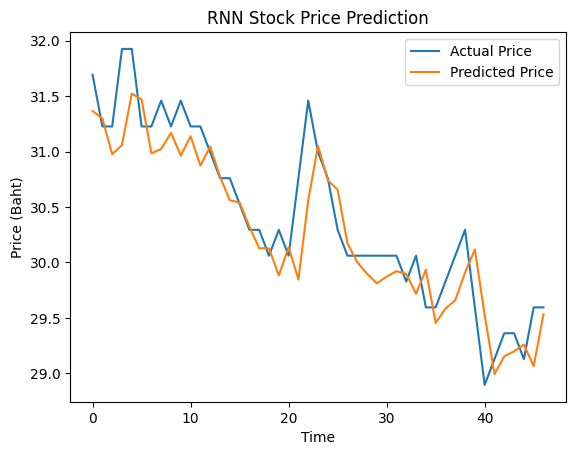

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# ---------------------------------------------------------------------
# 1️⃣ โหลดข้อมูลราคาหุ้น (DataFrame แบบ OHLC)
# ---------------------------------------------------------------------
# สมมติคุณมี DataFrame df ที่มีคอลัมน์: Date, Open, High, Low, Close
# ตัวอย่างนี้โหลดจากไฟล์ CSV หรือจาก yfinance ก็ได้

# 📌 ตัวอย่าง: ใช้ yfinance ดึงข้อมูลจริง (ต้อง pip install yfinance)
import yfinance as yf
df = yf.download("PTT.BK", start="2024-01-01", end="2025-01-01")
df = df[['Open', 'High', 'Low', 'Close']]
print(df.head())

# ---------------------------------------------------------------------
# 2️⃣ เตรียมข้อมูล
# ---------------------------------------------------------------------
# ใช้เฉพาะราคาปิด (Close)
data = df['Close'].values.reshape(-1, 1)

# สเกลข้อมูลให้อยู่ระหว่าง 0–1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# สร้างหน้าต่างเวลา (window) ย้อนหลัง N วัน
window_size = 10  # ใช้ราคาย้อนหลัง 10 วันเพื่อทำนายวันถัดไป
X, y = [], []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])  # 10 วันก่อนหน้า
    y.append(scaled_data[i, 0])                  # ราคาวันถัดไป

X, y = np.array(X), np.array(y)

# reshape เพื่อให้เข้ากับรูปแบบ RNN: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

# ---------------------------------------------------------------------
# 3️⃣ แบ่งข้อมูล Train/Test
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ---------------------------------------------------------------------
# 4️⃣ สร้างโมเดล RNN
# ---------------------------------------------------------------------
model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# ---------------------------------------------------------------------
# 5️⃣ ฝึกโมเดล
# ---------------------------------------------------------------------
history = model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

# ---------------------------------------------------------------------
# 6️⃣ ทำนายราคาวันถัดไป
# ---------------------------------------------------------------------
predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted.reshape(-1, 1))
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# ---------------------------------------------------------------------
# 7️⃣ แสดงผลลัพธ์
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt

plt.plot(real_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.title('RNN Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price (Baht)')
plt.legend()


#โค้ด 5.4 LSTM กำหนดเกต

In [ ]:
# =========================================
# Rule-based LSTM (RSI Gate) for Stock Price
# Predict Next-day Close Price
# =========================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

# -------------------------------
# 1) ตัวอย่างข้อมูล OHLC + RSI
# -------------------------------
# [Open, High, Low, Close, RSI]
data = np.array([
    [180, 185, 178, 183, 25],
    [183, 186, 181, 185, 35],
    [185, 188, 184, 187, 72],  # RSI > 70  -> SELL
    [187, 189, 185, 186, 65],
    [186, 190, 185, 188, 40],
], dtype=float)

X = data[:, :4]      # OHLC
rsi = data[:, 4]     # RSI

# ราคาปิด "วันถัดไป" (target)
y = np.array([185, 187, 186, 188, 190], dtype=float)

# -------------------------------
# 2) Normalize
# -------------------------------
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# reshape เป็น (batch, timesteps, features)
X_scaled = X_scaled.reshape(1, X_scaled.shape[0], X_scaled.shape[1])
y_scaled = y_scaled.reshape(1, -1, 1)

timesteps = X_scaled.shape[1]

# -------------------------------
# 3) สร้าง Rule-based Gates จาก RSI
# -------------------------------
# Forget gate
# - RSI > 70  -> ลืมความจำ (f = 0)
# - อื่น ๆ    -> จำทุกอย่าง
forget_gate = np.where(rsi > 70, 0.0, 1.0)

# Input gate
# - รับข้อมูลเฉพาะ RSI < 30 (oversold)
input_gate = np.where(rsi <= 70, 1.0, 0.0)

# Output gate
# - แสดงผลตลอด
output_gate = np.ones(timesteps)

# รวม gate
gates = np.stack([forget_gate, input_gate, output_gate], axis=1)

# -------------------------------
# 4) Custom Rule-based LSTM Cell
# -------------------------------
class RuleGateLSTMCell(tf.keras.layers.Layer):
    def __init__(self, units, gates):
        super().__init__()
        self.units = units
        self.gates = tf.constant(gates, dtype=tf.float32)
        self.state_size = [units, units]

    def build(self, input_shape):
        self.Wx = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="glorot_uniform"
        )
        self.Wh = self.add_weight(
            shape=(self.units, self.units),
            initializer="orthogonal"
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros"
        )

    def call(self, x, states, t):
        h_prev, c_prev = states

        # candidate cell
        c_bar = tf.tanh(x @ self.Wx + h_prev @ self.Wh + self.b)

        # rule-based gates
        f = self.gates[t, 0]  # forget
        i = self.gates[t, 1]  # input
        o = self.gates[t, 2]  # output

        # LSTM update
        c = f * c_prev + i * c_bar
        h = o * tf.tanh(c)

        return h, [h, c]

# -------------------------------
# 5) Model: Predict Next-day Price
# -------------------------------
class RuleBasedPriceModel(tf.keras.Model):
    def __init__(self, cell):
        super().__init__()
        self.cell = cell
        self.dense = layers.Dense(1)

    def call(self, X):
        # Use tf.shape(X)[0] to get the batch size dynamically, as X.shape[0] can be None during tracing
        batch = tf.shape(X)[0]
        timesteps = X.shape[1]
        features = X.shape[2]

        # Explicitly build the cell if it hasn't been built yet
        if not self.cell.built:
            self.cell.build(tf.TensorShape([None, features])) # Use None for batch size

        h = tf.zeros((batch, self.cell.units))
        c = tf.zeros((batch, self.cell.units))

        for t in range(timesteps):
            # Ensure to call the cell's call method explicitly or pass the argument correctly
            h, [h, c] = self.cell.call(X[:, t, :], [h, c], t)

        # ใช้ hidden state สุดท้าย -> ทำนายวันถัดไป
        return self.dense(h)

# -------------------------------
# 6) Train
# -------------------------------
cell = RuleGateLSTMCell(units=8, gates=gates)
model = RuleBasedPriceModel(cell)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse"
)

model.fit(
    X_scaled,
    y_scaled[:, -1],   # ราคาวันถัดไป
    epochs=500,
    verbose=0
)

# -------------------------------
# 7) Predict
# -------------------------------
pred_scaled = model(X_scaled)
pred_price = scaler_y.inverse_transform(pred_scaled.numpy())

print("Predicted next-day price:", float(pred_price[0, 0]))


Predicted next-day price: 190.0


# โค้ดที่มีการเรียนรู้เอง

In [ ]:
# =========================================
# LSTM with Learnable Gates
# Predict Next-day Stock Price (OHLC + RSI)
# =========================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# -------------------------------
# 1) ตัวอย่างข้อมูล OHLC + RSI
# -------------------------------
# [Open, High, Low, Close, RSI]
data = np.array([
    [180, 185, 178, 183, 25],
    [183, 186, 181, 185, 35],
    [185, 188, 184, 187, 72],
    [187, 189, 185, 186, 65],
    [186, 190, 185, 188, 40],
    [188, 192, 187, 191, 75],
    [191, 193, 188, 189, 28],
], dtype=float)

X = data[:, :5]   # OHLC + RSI

# ราคาปิด "วันถัดไป" (target)
y = np.array([
    185, 187, 186, 188, 191, 189, 192
], dtype=float)

# -------------------------------
# 2) Normalize
# -------------------------------
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# reshape เป็น (batch, timesteps, features)
X_scaled = X_scaled.reshape(1, X_scaled.shape[0], X_scaled.shape[1])
y_scaled = y_scaled.reshape(1, -1, 1)

# -------------------------------
# 3) สร้าง LSTM (เรียนรู้ gate เอง)
# -------------------------------
model = Sequential([
    LSTM(
        units=32,
        input_shape=(X_scaled.shape[1], X_scaled.shape[2]),
        return_sequences=False   # ใช้ hidden state ตัวสุดท้าย
    ),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse"
)

# -------------------------------
# 4) Train
# -------------------------------
model.fit(
    X_scaled,
    y_scaled[:, -1],   # ราคาวันถัดไป
    epochs=300,
    verbose=0
)

# -------------------------------
# 5) Predict next-day price
# -------------------------------
pred_scaled = model.predict(X_scaled)
pred_price = scaler_y.inverse_transform(pred_scaled)

print("Predicted next-day close price:", float(pred_price[0, 0]))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Predicted next-day close price: 192.0


#โค้ด 5.5 LSTM ไม่กำหนดเกต (ทำงานเป็น RNN) เรียกใช้ Model LSTM

/tmp/ipython-input-3655483364.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("PTT.BK", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Epoch 1/50



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1657
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0327
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0240
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0167
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0166
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0140
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0141
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0155
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0147
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0124
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0114
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0119
Epoch 13/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0141
Epoch 14/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0115
Epoch 15/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0123
Epoch 16/50
15/15 ━━━━

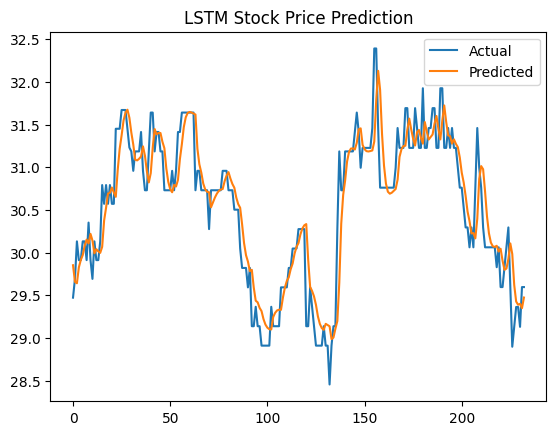

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# ดึงข้อมูลราคาหุ้นจริง
df = yf.download("PTT.BK", start="2024-01-01", end="2025-01-01")
data = df[['Close']].values

# สเกลข้อมูล
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# สร้างหน้าต่างเวลา
window_size = 10
X, y = [], []
for i in range(window_size, len(data_scaled)):
    X.append(data_scaled[i - window_size:i, 0])
    y.append(data_scaled[i, 0])

X, y = np.array(X), np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)

# สร้างโมเดล LSTM
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=50, batch_size=16, verbose=1)

# ทำนาย
pred = model.predict(X)
predicted = scaler.inverse_transform(pred)
real = scaler.inverse_transform(y.reshape(-1, 1))

# แสดงผล
plt.plot(real, label='Actual')
plt.plot(predicted, label='Predicted')
plt.title('LSTM Stock Price Prediction')
plt.legend()
plt.show()

#โค้ด 5.6 จำแนกสุนัข CNN

ต้อง mount ไปยังไดเรกทอรีที่เก็บรูปภาพก่อน

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/dataset

Mounted at /content/drive
cats  dogs


Found 16 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3125 - loss: 0.7207 - val_accuracy: 0.5000 - val_loss: 0.7162
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4375 - loss: 0.8342 - val_accuracy: 0.5000 - val_loss: 0.7344
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.3750 - loss: 0.7914 - val_accuracy: 0.5000 - val_loss: 0.7295
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.6250 - loss: 0.7640 - val_accuracy: 0.5000 - val_loss: 0.7131
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.5000 - loss: 0.7118 - val_accuracy: 0.2500 - val_loss: 0.7079
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.6875 - loss: 0.6628 - val_accuracy: 0.5000 - val_loss: 0.7086
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.5000 - loss: 0.7083 - val_accuracy: 0.5000 - val_loss: 0.7092
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/

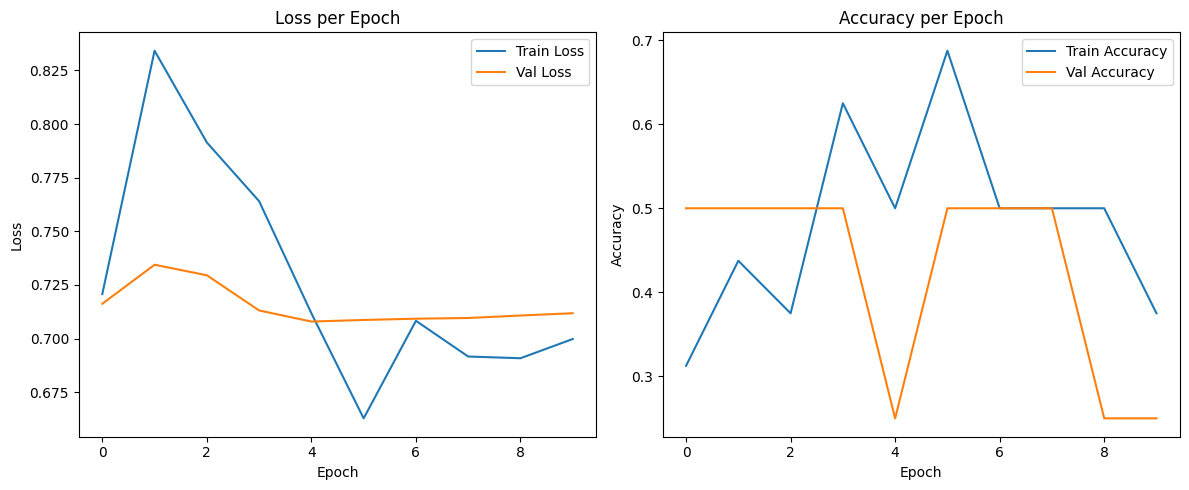

In [ ]:
# 1. กำหนดไลบรารีหรือแพ็กเกจที่จะใช้งาน
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# 2.เตรียมข้อมูลพิกเซลจะถูกแสดงด้วยเลขทศนิยมในช่วง 0-1 และแบ่งส่วน 20% เป็น test data
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
# 3. การเตรียมข้อมูลเข้าเพียงกำหนดไดเรกทอรีให้ถูกต้อง Tensorflow จะแบ่งข้อมูลออกเป็นคลาสตามชื่อไดเรกทอรีย่อย /cats และ /dogs ซึ่งอยู่ใน .../dataset/ ภาพแต่ละภาพจะถูกกำหนดให้มีขนาด 64x64 พิกเซล โหลดภาพครั้งละ 32 รูป แต่ถ้ามีน้อยกว่านั้นภาพจะถูกโหลดมาทั้งหมดครั้งเดียว ปัญหานี้เป็นปัญหาการจำแนกกำหนดด้วยคำสั่ง class_mode = ‘binary’ ส่วนนี้จัดการกับข้อมูลที่เป็น training set
train_data = datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset/',     #Mount ไปหาข้อมูลใน Google Drive
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='training'
)
# 4. การเตรียมข้อมูลเข้า ส่วนนี้จัดการกับข้อมูลที่เป็น validation set
val_data = datagen.flow_from_directory(
     '/content/drive/MyDrive/dataset/',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)
# 5. สร้างโมเดล
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
# 6. ฝึกโมเดล
history = model.fit(train_data, validation_data=val_data, epochs=10)


# 7. แสดง Loss และ Accuracy ของแต่ละ epoch
print("\n=== Training History ===")
for epoch in range(len(history.history['loss'])):
    print(f"Epoch {epoch+1}: "
          f"Loss = {history.history['loss'][epoch]:.4f}, "
          f"Val Loss = {history.history['val_loss'][epoch]:.4f}, "
          f"Accuracy = {history.history['accuracy'][epoch]:.4f}, "
          f"Val Accuracy = {history.history['val_accuracy'][epoch]:.4f}")

# 8. Plot กราฟ Loss และ Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()
